# This Jupyter notebook file produces the behavioral results in the paper

In [1]:
import numpy as np
import scipy
import mat73
import sklearn
from utility_functions import *
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as Patches
plt.rcParams["axes.linewidth"] = 2
plt.rcParams["axes.edgecolor"] = 'k'
plt.rcParams['grid.alpha'] = 0

# Load the data and meta data
 Here we need to load the entire trials. So `data_type` should be "trials"

In [2]:
data_type='trials' # this could be 'trials', 'last4s', 'first4s'.
monkey='C' # monkey should be one of 'C', 'J' or 'M'
CE=81 # channel name. NOTE: this is not the channel number or the channel index

# load the raw data
raw_data=load_ONF_data(data_type, monkey, CE)

Optional: Visualize the data table. This may take some time.

In [6]:
raw_data

,file_num,file_types,num_success,num_failed,success_rate,spike_rate,HGA,target_types,velocity,position,trial_types,date
0,07312013004,learning curve,22.0,84.0,0.20754716981132076,[[[[31.73602011 40.97333641 40.61768382 33.938...,[[[[-5.2070837 -4.927527 -3.8137338 -5.079105...,"[1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[[[[-41.47388205 10.22238639], [-43.9242644 ...","[[[[0.4614054 1.02620305], [-0.29195607 0.80...","[-1.0, -1.0, 1.0, 1.0, -1.0, -1.0, -1.0, 1.0, ...",2013-07-31
1,07312013005,learning curve,27.0,86.0,0.23893805309734514,[[[[50.70839569 46.7991819 36.82583761 36.012...,[[[[-0.95756286 0.7184177 -1.6495833 -1.134...,"[1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, ...","[[[[-19.2573856 2.8446152], [-19.26800862 ...","[[[[ 1.72360075 -0.27336959], [ 2.04225849 -0....","[1.0, 1.0, 1.0, -1.0, 1.0, -1.0, 1.0, 1.0, -1....",2013-07-31
2,07312013006,learning curve,32.0,81.0,0.2831858407079646,[[[[48.33316538 38.52003866 37.05967885 40.224...,[[[[-3.0274253 -4.7622247 -4.093817 -4.506363...,"[1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, ...","[[[[-14.87505108 10.89788 ], [-17.2338138 ...","[[[[1.39830203 0.78827849], [1.69081929 0.8303...","[-1.0, -1.0, 1.0, 1.0, 1.0, -1.0, 1.0, -1.0, -...",2013-07-31
3,07312013007,learning curve,34.0,86.0,0.2833333333333333,[[[[41.4042628 49.31564691 49.06427121 35.633...,[[[[-0.74001557 -0.6033354 -2.564933 -3.805...,"[0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, ...","[[[[-26.92730143 7.38241007], [-25.22499317 ...","[[[[-0.91981587 1.62922073], [-0.90060134 1....","[1.0, -1.0, 1.0, 1.0, 1.0, -1.0, 1.0, -1.0, -1...",2013-07-31
4,08012013002,learned,45.0,74.0,0.37815126050420167,[[[[37.78219587 34.83355969 21.30376545 11.654...,[[[[-1.2955235 0.19664705 -2.5070179 -1.402...,"[1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, ...","[[[[-31.78944304 4.00952926], [-32.83597696 ...","[[[[-0.23667226 -1.26665779], [-0.96468212 -1....","[-1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0, -1.0, 1....",2013-08-01
5,08012013004,learning curve,35.0,79.0,0.30701754385964913,[[[[58.588061 61.43690895 49.95436835 41.154...,[[[[-3.1877716 -2.1766863 -1.118843 0.214...,"[0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, ...","[[[[-13.85437739 6.62923029], [-7.04332494 ...","[[[[ 0.72586888 -0.25480414], [ 1.29569535 -0....","[-1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0, 1.0, 1...",2013-08-01
6,08012013005,learning curve,30.0,51.0,0.37037037037037035,[[[[46.51184249 46.85921139 47.45696083 39.076...,[[[[-3.0686214 -2.8818908 -3.194589 -3.642...,"[1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, ...","[[[[-20.15957911 5.09411593], [-17.89956579 ...","[[[[ 1.40382273 -0.8062285 ], [ 1.41326294 -1....","[-1.0, 1.0, 1.0, -1.0, 1.0, -1.0, -1.0, 1.0, 1...",2013-08-01
7,08012013006,learning curve,24.0,35.0,0.4067796610169492,[[[[62.92232974 52.39824473 40.21552771 36.638...,[[[[-4.9805923 -4.155403 -4.3175173 -3.066...,"[1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, ...","[[[[-33.47297252 15.29349293], [-36.05534255 ...","[[[[-0.77267968 -0.71279886], [-1.66344458 -0....","[-1.0, 1.0, 1.0, -1.0, -1.0, 1.0, -1.0, -1.0, ...",2013-08-01
8,08012013007,learning curve,26.0,48.0,0.35135135135135137,[[[[43.61308776 49.21495094 45.94493791 46.906...,[[[[-1.1120985 -1.8589423 -4.017859 -3.296...,"[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, ...","[[[[-15.70325423 3.08426991], [-20.29873225 ...","[[[[ 0.74827801 -1.03435403], [ 0.62495925 -1....","[1.0, 1.0, -1.0, 1.0, -1.0, -1.0, 1.0, -1.0, -...",2013-08-01
9,08022013002,learned,49.0,41.0,0.5444444444444444,[[[[41.17127438 40.74463086 39.5816512 37.770...,[[[[-3.1443639 -2.5824733 -2.01486 -0.491...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ...","[[[[-8.87993552 16.43822088], [-13.77009195 ...","[[[[0.93266359 1.0695934 ], [1.2017433 0.7525...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",2013-08-02


# Plot the cursor traces arranged by days

In [13]:
# group position, velocity, trial types, target types data by days
position_day=file_2_day(raw_data, 'position',axis=-1)
velocity_day=file_2_day(raw_data,'velocity',axis=-1)
trial_types_day=file_2_day(raw_data,'trial_types',axis=-1)
target_types_day=file_2_day(raw_data,'target_types',axis=-1)
n_days=len(position_day)

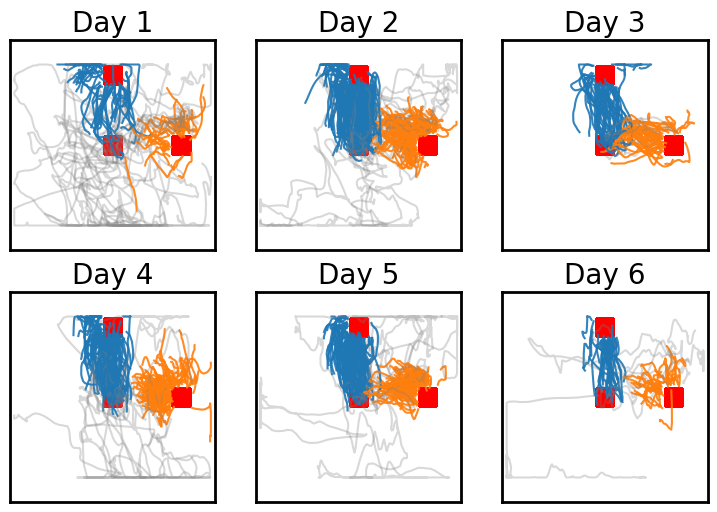

In [15]:
# Visualize the cursor trace

# get automatic row and column number
row,col,res=closest_factors_decomposition(n_days)
# specify the time length from the reward to look at
max_bins=20 # 20 bins at 50 ms bins is 1000 ms
# save the trial type
all_trial_type_indices=[]

# plot the traces based on days
fig,ax=plt.subplots(row,col,figsize=(col*3,row*3))
ax=ax.flatten()
for i in range(row*col): # each day
    if i <n_days:
        pos=position_day[i]
        trial_type=[]
        for e, p in enumerate(pos): # each trial

            # draw the targets
            ax[i].add_patch(Patches.Rectangle((-1.25, 8.75), 2.5, 2.5,color='red'))
            ax[i].add_patch(Patches.Rectangle((8.75,-1.25), 2.5, 2.5,color='red'))
            ax[i].add_patch(Patches.Rectangle((-1.25,-1.25), 2.5, 2.5,color='red'))

            if trial_types_day[i][e]==1: # if they are successful trials
                if len(p[0])>max_bins:
                    p=p[0][-max_bins:,:]
                else:
                    p=p[0]

                # draw the traces
                if p[-1,1]<5:# last frame of x position: This is an HG target trial
                    trial_type.append(1)
                    ax[i].plot(p[:,0],p[:,1],color='tab:orange',alpha=0.9)
                else: # This is a spike target trial
                    trial_type.append(0)
                    ax[i].plot(p[:,0],p[:,1],color='tab:blue',alpha=0.9)
            else: # if they are failed trials
                if len(p[0].shape)==1:
                    p=p[0][None,:]
                else:
                    p=p[0]
                if target_types_day[i][e]==0: # This is a spike target trial
                    trial_type.append(0)
                else: # This is a HG target trial
                    trial_type.append(1)
                ax[i].plot(p[:,0],p[:,1],color='grey',alpha=0.3)

            # set the boundaries of the traces
            ax[i].set_ylim([-15,15])
            ax[i].set_xlim([-15,15])
            ax[i].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False)

        ax[i].set_title(f"Day {i+1}",fontsize=20)
        ax[i].spines[['left','top','bottom','right']].set_linewidth(2)
        ax[i].spines[['left','top','bottom','right']].set_color('k')
        ax[i].grid(False)
        all_trial_type_indices.append(trial_type)
    else:
        ax[i].axis('off')
plt.show()


### Calculate and visualize the behavioral metrics
1. success rate
2. time to target
3. path length
4. takeoff angle
5. entry angle

In [31]:
# the variability of successful trials approaching the target in x and y direction
# total variability = sqrt(x^2+y^2) for each type of trials
min_length=10 # we want to look at 500 ms of data, which is 10 bins
cumulative=0


path_length_all=[]
speed=[]
all_TTT=[]
entry_angles_1=[]
entry_angles_2=[]

takeoff_angles_1=[]
takeoff_angles_2=[]

for i in range(n_days):
    pos=position_day[i]
    # calculate takeoff angle
    to_angles_hg=[]
    to_angles_sp=[]
    # calculate time to target
    TTT=[]
    # calculate path length
    pl_all=[]

    for j,pos_trial in enumerate(pos):
        if len(np.shape(pos_trial[0]))==2:
            pos_trial=pos_trial[0] # this should be a n_bin x (x,y) matrix
            TTT.append(len(pos_trial)*50/1000)
            o=all_trial_type_indices[i][j]
            max_length=np.minimum(20,len(pos_trial)-1) # first 10 bins (should be 100ms)
            angle=np.arctan2(pos_trial[max_length,1]-pos_trial[0,1],pos_trial[max_length,0]-pos_trial[0,0])
            path_length=np.sqrt(np.sum(np.diff(pos_trial,axis=0)**2))
            pl_all.append(path_length)
            if o ==0:
                to_angles_sp.append(angle)
            elif  o==1:
                to_angles_hg.append(angle)
            else:
                raise Exception
    all_TTT.append(np.mean(TTT))

    to_angles_sp=np.rad2deg(np.array(to_angles_sp))
    to_angles_hg=np.rad2deg(np.array(to_angles_hg))

    # find the peak of the distribution
    hist_hg,bins_hg=np.histogram(to_angles_hg,bins=20)
    hist_sp,bins_sp=np.histogram(to_angles_sp,bins=20)

    id_max_hg=np.argmax(hist_hg[10:])+10
    id_max_sp=np.argmax(hist_sp[8:])+8

    takeoff_angles_1.append(bins_hg[id_max_hg])
    takeoff_angles_2.append(bins_sp[id_max_sp])

    # calculate path length
    pos_all=np.array([p[0] for p in pos],dtype=object)
    path_length_all.append(np.mean(pl_all))

    # get other behavioral metrics
    trial_type=np.array(all_trial_type_indices[i][:len(pos)])
    long_trials=[1 if len(p[0]) > min_length else 0 for p in pos] # this also take care of len(p[0].shape)<2.
    pos=np.array([p[0][-min_length:] for p,l in zip(pos,long_trials) if l])
    trial_type=trial_type[np.array(long_trials)==1]
    vel=np.array([np.diff(p,axis=-1) for p in pos])

    entry_angles_1.append(np.median(np.arctan2(pos[trial_type==1,-1,1]-pos[trial_type==1,0,1],
                           pos[trial_type==1,-1,0]-pos[trial_type==1,0,0])))
    entry_angles_2.append(np.median(np.arctan2(pos[trial_type!=1,-1,1]-pos[trial_type!=1,0,1],
                           pos[trial_type!=1,-1,0]-pos[trial_type!=1,0,0])))

    speed.append(np.mean(np.square(vel).sum(axis=-1).mean(axis=1)))
    cumulative+=1


Visualizing the behavioral metrics for this monkey-CE

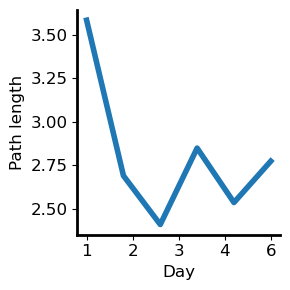

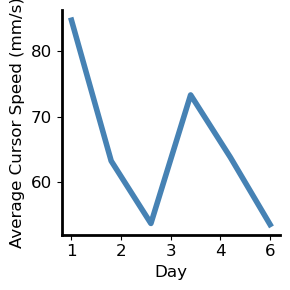

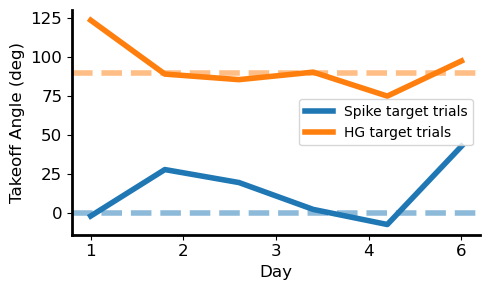

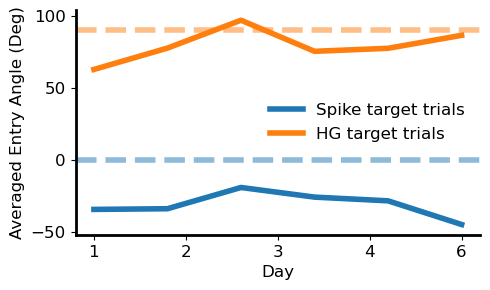

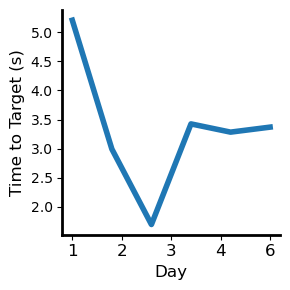

In [34]:
# Path length
fig,ax=plt.subplots(1,1,figsize=(3,3))
ax.plot(list(range(n_days)),path_length_all,color='Tab:blue',linewidth=4)
ax.set_ylabel("Path length",fontsize=12)
ax.set_xticks(ticks=np.linspace(0,n_days-1,5),labels=[str(int(i+1)) for i in np.linspace(0,n_days-1,5)],fontsize=12)
ax.set_xlabel("Day",fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(2)
plt.tight_layout()

# Average speed
fig,ax=plt.subplots(1,1,figsize=(3,3))
ax.plot(speed,color='steelblue',linewidth=4)
ax.set_ylabel("Average Cursor Speed (mm/s)",fontsize=12)
ax.set_xticks(ticks=np.linspace(0,n_days-1,5),labels=[str(int(i+1)) for i in np.linspace(0,n_days-1,5)],fontsize=12)
ax.set_xlabel("Day",fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(2)
plt.tight_layout()

# Takeoff angle
fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(takeoff_angles_1,color='tab:blue',linewidth=4,label='Spike target trials')
ax.plot(takeoff_angles_2,color='tab:orange',linewidth=4,label='HG target trials')
ax.axhline(y=0,color='tab:blue',linestyle='--',linewidth=4,alpha=0.5)
ax.axhline(y=90,color='tab:orange',linestyle='--',linewidth=4,alpha=0.5)
ax.legend()
ax.set_ylabel("Takeoff Angle (deg)",fontsize=12)
ax.set_xticks(ticks=np.linspace(0,n_days-1,5),labels=[str(int(i+1)) for i in np.linspace(0,n_days-1,5)],fontsize=12)
ax.set_xlabel("Day",fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(2)
plt.tight_layout()

# Entry angle
fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(np.rad2deg(entry_angles_1),color='Tab:blue',linewidth=4)
ax.plot(np.rad2deg(entry_angles_2),color='Tab:orange',linewidth=4)
ax.axhline(90,color='Tab:orange',linestyle='--',alpha=0.5,linewidth=4)
ax.axhline(0,color='Tab:blue',linestyle='--',alpha=0.5,linewidth=4)
ax.legend(["Spike target trials","HG target trials"],frameon=False, fontsize=12)
ax.set_ylabel(f"Averaged Entry Angle (Deg)",fontsize=12)
ax.set_xticks(ticks=np.linspace(0,n_days-1,5),labels=[str(int(i+1)) for i in np.linspace(0,n_days-1,5)],fontsize=12)
ax.set_xlabel("Day",fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(2)
plt.tight_layout()


# Time to Target
fig,ax=plt.subplots(1,1,figsize=(3,3))
ax.plot(all_TTT,color='tab:blue',linewidth=4)
ax.set_ylabel("Time to Target (s)",fontsize=12)
ax.set_xticks(ticks=np.linspace(0,n_days-1,5),labels=[str(int(i+1)) for i in np.linspace(0,n_days-1,5)],fontsize=12)
ax.set_xlabel("Day",fontsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(2)
plt.tight_layout()
plt.show()